# Tahap 5 - Model Evaluation

Project: Case-Based Reasoning untuk Pidana Umum - Pencurian di PN Tangerang

Notebook ini digunakan sebagai bagian dari pipeline CBR.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
import re
import joblib
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

BASE_DIR = Path("..").resolve()

PROCESSED_DIR = BASE_DIR / "data" / "processed"
EVAL_DIR = BASE_DIR / "data" / "eval"
RESULTS_DIR = BASE_DIR / "data" / "results"

EVAL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

cases_path = PROCESSED_DIR / "cases.csv"
queries_path = EVAL_DIR / "queries.json"

vectorizer_path = PROCESSED_DIR / "tfidf_vectorizer.joblib"
matrix_path = PROCESSED_DIR / "tfidf_matrix.joblib"

cases_df = pd.read_csv(cases_path, dtype=str).fillna("")

print("Jumlah kasus:", len(cases_df))

with open(queries_path, "r", encoding="utf-8") as f:
    eval_queries = json.load(f)

print("Jumlah query evaluasi:", len(eval_queries))

cases_df.head()

Jumlah kasus: 40
Jumlah query evaluasi: 10


,case_id,no_perkara,tanggal_putusan,pengadilan,jenis_perkara,penuntut_umum,terdakwa,pasal,hakim_ketua,hakim_anggota,...,tanggal_dibacakan,ringkasan_fakta,argumen_hukum,solution_text,solution_label,lama_pidana,sumber_url,raw_file,jumlah_kata,text_full
0,case_001,1022/Pid.B/2010/PN.TNG,14 Juli 2010,PN Tangerang,Pidana Umum - Pencurian,,JAMALUDIN Bin SANIF terbukti secara sah danmey...,Pasal 363 ayat (2) KUHP; Pasal 363,,,...,,Pengadilan PN TANGERANG Pidana Umum Kejahatan ...,,,Lain-lain,,https://putusan3.mahkamahagung.go.id/direktori...,case_001.txt,80,Pengadilan PN TANGERANG Pidana Umum Kejahatan ...
1,case_002,497 / PID.B / 2014 / PN.TNG.,19 Mei 2014,PN Tangerang,Pidana Umum - Pencurian,;Menjatuhkan pidana penjara terhadap,AMIN Als. UBE Bin UDIN danALIP KURNIAWAN Als. ...,Pasal 365 ayat (2) ke2 KUHP; Pasal 365,,,...,,Pengadilan PN TANGERANG Pidana Umum Pencurian ...,,,Lain-lain,,https://putusan3.mahkamahagung.go.id/direktori...,case_002.txt,322,Pengadilan PN TANGERANG Pidana Umum Pencurian ...
2,case_003,1885 /Pid.B/2011/PN.TNG,15 Desember 2011,PN Tangerang,Pidana Umum - Pencurian,,MAULANAHASANUDIN als. KEDOK binROJALI telah te...,,,,...,,Pengadilan PN TANGERANG Pidana Umum Kejahatan ...,,,Lain-lain,,https://putusan3.mahkamahagung.go.id/direktori...,case_003.txt,123,Pengadilan PN TANGERANG Pidana Umum Kejahatan ...
3,case_004,1073/Pid.B/2019/PN Tng,10 Juli 2019,PN Tangerang,Pidana Umum - Pencurian,"REZA VAHLEVI, SH",MUHAMMAD RIKI YAKUB Alias INYONG Bin RIPIN 37 ...,Pasal 362 KUHP; Pasal 362,,,...,,Pengadilan PN TANGERANG Pidana Umum Register :...,,,Lain-lain,,https://putusan3.mahkamahagung.go.id/direktori...,case_004.txt,213,Pengadilan PN TANGERANG Pidana Umum Register :...
4,case_005,678/ PID.B/ 2011/ PN TNG,8 Mei 2012,PN Tangerang,Pidana Umum - Pencurian,di mukapersidangan ;Telah mendengar keterangan...,di persidangan ;Telah mendengar pembacaan tunt...,Pasal 362 KUHP; Pasal 362,,,...,,Pengadilan PN TANGERANG Pidana Umum Pencurian ...,,,Lain-lain,,https://putusan3.mahkamahagung.go.id/direktori...,case_005.txt,342,Pengadilan PN TANGERANG Pidana Umum Pencurian ...


In [2]:
def clean_text_for_retrieval(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s./-]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def build_retrieval_text(row):
    parts = [
        row.get("no_perkara", ""),
        row.get("pengadilan", ""),
        row.get("jenis_perkara", ""),
        row.get("terdakwa", ""),
        row.get("pasal", ""),
        row.get("amar_lainnya", ""),
        row.get("catatan_amar", ""),
        row.get("ringkasan_fakta", ""),
        row.get("argumen_hukum", ""),
        row.get("solution_text", ""),
        row.get("text_full", "")
    ]
    
    return clean_text_for_retrieval(" ".join([str(p) for p in parts if str(p).strip() != ""]))


if "retrieval_text" not in cases_df.columns:
    cases_df["retrieval_text"] = cases_df.apply(build_retrieval_text, axis=1)


if vectorizer_path.exists() and matrix_path.exists():
    vectorizer = joblib.load(vectorizer_path)
    tfidf_matrix = joblib.load(matrix_path)
    print("Vectorizer dan matrix berhasil diload.")
else:
    print("Vectorizer belum ditemukan. Membuat ulang TF-IDF...")
    
    vectorizer = TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        max_features=5000,
        min_df=1
    )
    
    tfidf_matrix = vectorizer.fit_transform(cases_df["retrieval_text"])
    
    joblib.dump(vectorizer, vectorizer_path)
    joblib.dump(tfidf_matrix, matrix_path)
    
    print("TF-IDF berhasil dibuat ulang.")


def retrieve(query: str, k: int = 5):
    query_clean = clean_text_for_retrieval(query)
    query_vector = vectorizer.transform([query_clean])
    
    similarities = cosine_similarity(query_vector, tfidf_matrix).flatten()
    top_indices = similarities.argsort()[::-1][:k]
    
    results = cases_df.iloc[top_indices].copy()
    results["similarity_score"] = similarities[top_indices]
    
    return results

Vectorizer dan matrix berhasil diload.


In [3]:
def eval_retrieval(eval_queries, k=5):
    rows = []
    
    for item in eval_queries:
        query_id = item.get("query_id", "")
        query = item.get("query", "")
        ground_truth_case_id = item.get("ground_truth_case_id", "")
        
        top_k = retrieve(query, k=k)
        
        top_case_ids = top_k["case_id"].tolist()
        top_scores = top_k["similarity_score"].round(4).tolist()
        
        top1_case_id = top_case_ids[0] if top_case_ids else ""
        
        hit_at_k = 1 if ground_truth_case_id in top_case_ids else 0
        top1_correct = 1 if ground_truth_case_id == top1_case_id else 0
        
        precision_at_k = hit_at_k / k
        recall_at_k = hit_at_k
        
        if precision_at_k + recall_at_k == 0:
            f1_at_k = 0
        else:
            f1_at_k = 2 * (precision_at_k * recall_at_k) / (precision_at_k + recall_at_k)
        
        rows.append({
            "query_id": query_id,
            "ground_truth_case_id": ground_truth_case_id,
            "top1_case_id": top1_case_id,
            "top_k_case_ids": ", ".join(top_case_ids),
            "top_k_scores": ", ".join([str(s) for s in top_scores]),
            "top1_correct": top1_correct,
            "hit_at_k": hit_at_k,
            "precision_at_k": precision_at_k,
            "recall_at_k": recall_at_k,
            "f1_at_k": f1_at_k
        })
    
    return pd.DataFrame(rows)


retrieval_eval_df = eval_retrieval(eval_queries, k=5)

retrieval_eval_path = EVAL_DIR / "retrieval_eval_detail.csv"
retrieval_eval_df.to_csv(retrieval_eval_path, index=False)

print("Detail evaluasi retrieval disimpan:")
print(retrieval_eval_path)

retrieval_eval_df

Detail evaluasi retrieval disimpan:
/home/zack/Penalaran-Komputer-subcpmk-3/data/eval/retrieval_eval_detail.csv


,query_id,ground_truth_case_id,top1_case_id,top_k_case_ids,top_k_scores,top1_correct,hit_at_k,precision_at_k,recall_at_k,f1_at_k
0,eval_001,case_020,case_020,"case_020, case_018, case_033, case_037, case_038","0.8744, 0.3464, 0.2744, 0.2585, 0.2533",1,1,0.2,1,0.333333
1,eval_002,case_017,case_017,"case_017, case_010, case_016, case_033, case_002","0.9297, 0.1242, 0.1215, 0.1204, 0.1171",1,1,0.2,1,0.333333
2,eval_003,case_016,case_016,"case_016, case_007, case_015, case_008, case_032","0.9202, 0.1379, 0.1324, 0.13, 0.1281",1,1,0.2,1,0.333333
3,eval_004,case_027,case_027,"case_027, case_031, case_015, case_039, case_026","0.9831, 0.3037, 0.253, 0.2258, 0.2195",1,1,0.2,1,0.333333
4,eval_005,case_005,case_005,"case_005, case_003, case_033, case_037, case_006","0.8864, 0.1861, 0.1572, 0.1555, 0.146",1,1,0.2,1,0.333333
5,eval_006,case_013,case_013,"case_013, case_011, case_023, case_015, case_012","0.9822, 0.146, 0.1456, 0.1438, 0.1399",1,1,0.2,1,0.333333
6,eval_007,case_038,case_038,"case_038, case_020, case_018, case_002, case_003","0.9542, 0.3592, 0.283, 0.2043, 0.1336",1,1,0.2,1,0.333333
7,eval_008,case_028,case_028,"case_028, case_023, case_015, case_026, case_032","0.982, 0.2588, 0.2576, 0.246, 0.2249",1,1,0.2,1,0.333333
8,eval_009,case_040,case_040,"case_040, case_001, case_003, case_025, case_036","0.99, 0.1791, 0.1224, 0.1138, 0.0923",1,1,0.2,1,0.333333
9,eval_010,case_007,case_007,"case_007, case_016, case_008, case_037, case_030","0.9521, 0.1623, 0.1401, 0.1386, 0.1188",1,1,0.2,1,0.333333


In [4]:
retrieval_metrics = {
    "top1_accuracy": retrieval_eval_df["top1_correct"].mean(),
    "hit_rate_at_5": retrieval_eval_df["hit_at_k"].mean(),
    "precision_at_5": retrieval_eval_df["precision_at_k"].mean(),
    "recall_at_5": retrieval_eval_df["recall_at_k"].mean(),
    "f1_at_5": retrieval_eval_df["f1_at_k"].mean()
}

retrieval_metrics_df = pd.DataFrame([
    {"metric": key, "value": value}
    for key, value in retrieval_metrics.items()
])

retrieval_metrics_path = EVAL_DIR / "retrieval_metrics.csv"
retrieval_metrics_df.to_csv(retrieval_metrics_path, index=False)

print("Retrieval metrics:")
display(retrieval_metrics_df)

print("File disimpan:")
print(retrieval_metrics_path)

Retrieval metrics:


,metric,value
0,top1_accuracy,1.000000
1,hit_rate_at_5,1.000000
2,precision_at_5,0.200000
3,recall_at_5,1.000000
4,f1_at_5,0.333333


File disimpan:
/home/zack/Penalaran-Komputer-subcpmk-3/data/eval/retrieval_metrics.csv


In [5]:
def weighted_vote_solution(top_k_df):
    label_scores = {}
    
    for _, row in top_k_df.iterrows():
        label = row.get("solution_label", "Lain-lain")
        score = float(row.get("similarity_score", 0))
        
        if label not in label_scores:
            label_scores[label] = 0
        
        label_scores[label] += score
    
    if not label_scores:
        return "Lain-lain"
    
    return max(label_scores, key=label_scores.get)


def predict_solution_label(query: str, k: int = 5):
    top_k = retrieve(query, k=k)
    predicted_label = weighted_vote_solution(top_k)
    
    best_case_id = top_k.iloc[0]["case_id"]
    
    return predicted_label, best_case_id


prediction_rows = []

for item in eval_queries:
    query_id = item.get("query_id", "")
    query = item.get("query", "")
    ground_truth_solution_label = item.get("ground_truth_solution_label", "")
    
    predicted_label, best_case_id = predict_solution_label(query, k=5)
    
    prediction_rows.append({
        "query_id": query_id,
        "ground_truth_solution_label": ground_truth_solution_label,
        "predicted_solution_label": predicted_label,
        "best_case_id": best_case_id
    })

prediction_eval_df = pd.DataFrame(prediction_rows)

prediction_eval_path = EVAL_DIR / "prediction_eval_detail.csv"
prediction_eval_df.to_csv(prediction_eval_path, index=False)

prediction_eval_df

,query_id,ground_truth_solution_label,predicted_solution_label,best_case_id
0,eval_001,Lain-lain,Lain-lain,case_020
1,eval_002,Lain-lain,Lain-lain,case_017
2,eval_003,Lain-lain,Lain-lain,case_016
3,eval_004,Lain-lain,Lain-lain,case_027
4,eval_005,Lain-lain,Lain-lain,case_005
5,eval_006,Lain-lain,Lain-lain,case_013
6,eval_007,Lain-lain,Lain-lain,case_038
7,eval_008,Lain-lain,Lain-lain,case_028
8,eval_009,Lain-lain,Lain-lain,case_040
9,eval_010,Lain-lain,Lain-lain,case_007


In [6]:
y_true = prediction_eval_df["ground_truth_solution_label"]
y_pred = prediction_eval_df["predicted_solution_label"]

prediction_metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
    "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
    "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
}

prediction_metrics_df = pd.DataFrame([
    {"metric": key, "value": value}
    for key, value in prediction_metrics.items()
])

prediction_metrics_path = EVAL_DIR / "prediction_metrics.csv"
prediction_metrics_df.to_csv(prediction_metrics_path, index=False)

print("Prediction metrics:")
display(prediction_metrics_df)

print("File disimpan:")
print(prediction_metrics_path)

Prediction metrics:


,metric,value
0,accuracy,1.0
1,precision_macro,1.0
2,recall_macro,1.0
3,f1_macro,1.0
4,precision_weighted,1.0
5,recall_weighted,1.0
6,f1_weighted,1.0


File disimpan:
/home/zack/Penalaran-Komputer-subcpmk-3/data/eval/prediction_metrics.csv


In [7]:
failure_df = retrieval_eval_df[
    retrieval_eval_df["hit_at_k"] == 0
].copy()

failure_path = EVAL_DIR / "failure_analysis.csv"
failure_df.to_csv(failure_path, index=False)

print("Jumlah query gagal retrieval:", len(failure_df))
print("File failure analysis:", failure_path)

failure_df

Jumlah query gagal retrieval: 0
File failure analysis: /home/zack/Penalaran-Komputer-subcpmk-3/data/eval/failure_analysis.csv


,query_id,ground_truth_case_id,top1_case_id,top_k_case_ids,top_k_scores,top1_correct,hit_at_k,precision_at_k,recall_at_k,f1_at_k


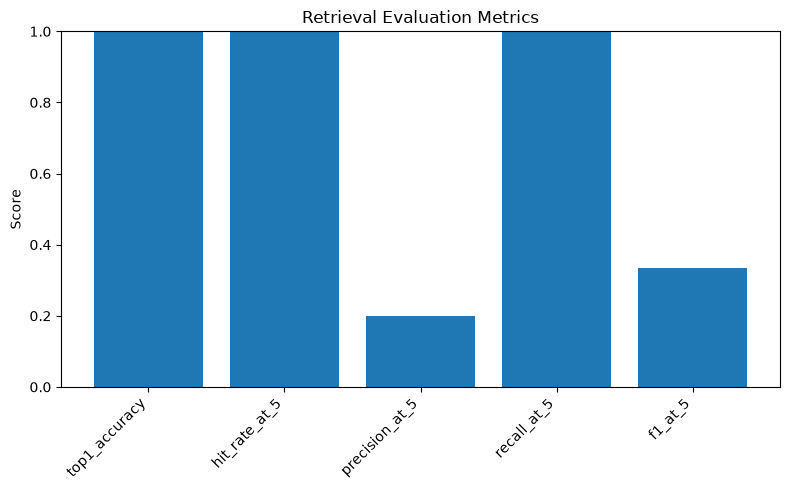

Plot retrieval disimpan:
/home/zack/Penalaran-Komputer-subcpmk-3/data/results/retrieval_metrics_bar.png


In [8]:
plt.figure(figsize=(8, 5))
plt.bar(retrieval_metrics_df["metric"], retrieval_metrics_df["value"])
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.title("Retrieval Evaluation Metrics")
plt.ylabel("Score")
plt.tight_layout()

retrieval_plot_path = RESULTS_DIR / "retrieval_metrics_bar.png"
plt.savefig(retrieval_plot_path, dpi=300)
plt.show()

print("Plot retrieval disimpan:")
print(retrieval_plot_path)

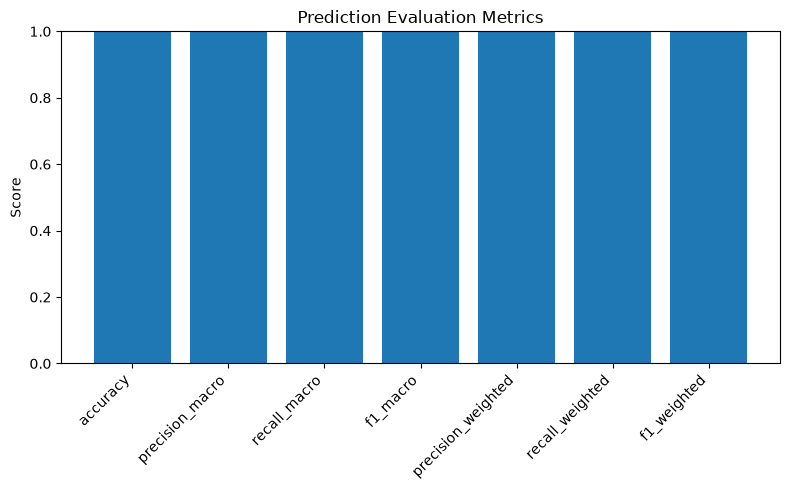

Plot prediction disimpan:
/home/zack/Penalaran-Komputer-subcpmk-3/data/results/prediction_metrics_bar.png


In [9]:
plt.figure(figsize=(8, 5))
plt.bar(prediction_metrics_df["metric"], prediction_metrics_df["value"])
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.title("Prediction Evaluation Metrics")
plt.ylabel("Score")
plt.tight_layout()

prediction_plot_path = RESULTS_DIR / "prediction_metrics_bar.png"
plt.savefig(prediction_plot_path, dpi=300)
plt.show()

print("Plot prediction disimpan:")
print(prediction_plot_path)

In [10]:
output_files = [
    retrieval_eval_path,
    retrieval_metrics_path,
    prediction_eval_path,
    prediction_metrics_path,
    failure_path,
    retrieval_plot_path,
    prediction_plot_path
]

for file in output_files:
    print(file, "=>", file.exists())

/home/zack/Penalaran-Komputer-subcpmk-3/data/eval/retrieval_eval_detail.csv => True
/home/zack/Penalaran-Komputer-subcpmk-3/data/eval/retrieval_metrics.csv => True
/home/zack/Penalaran-Komputer-subcpmk-3/data/eval/prediction_eval_detail.csv => True
/home/zack/Penalaran-Komputer-subcpmk-3/data/eval/prediction_metrics.csv => True
/home/zack/Penalaran-Komputer-subcpmk-3/data/eval/failure_analysis.csv => True
/home/zack/Penalaran-Komputer-subcpmk-3/data/results/retrieval_metrics_bar.png => True
/home/zack/Penalaran-Komputer-subcpmk-3/data/results/prediction_metrics_bar.png => True
